# Aperta minimal example

Walkable supermarkets in Cambridge, MA — end-to-end in ~40 lines using
only OpenStreetMap. Runs in ~10–15 s on a laptop.

Every aperta primitive is exercised exactly once, with no commentary.
For the guided tour see
[`walkthrough/accessibility.ipynb`](../walkthrough/accessibility.ipynb);
for a production-scale demo see [`extended/`](../extended/).

In [1]:
import matplotlib.pyplot as plt
import osmnx as ox
import geopandas as gpd

import aperta.accessibility as accessibility
import aperta.geo_mapping as geo_mapping
import aperta.geo_processing as geo_processing
import aperta.network_processing as network_processing
import aperta.od_pairs as od_pairs
import aperta.routing as routing
import aperta.visualization as viz

PLACE = 'Cambridge, Massachusetts, USA'

/opt/miniconda3/envs/aperta/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1. AOI + walking network

In [2]:
boundary = ox.geocode_to_gdf(PLACE)
crs = boundary.estimate_utm_crs()
graph = ox.project_graph(
    ox.graph_from_place(PLACE, network_type='walk', simplify=True),
    to_crs=crs,
).to_undirected()  # pedestrians ignore one-ways

## 2. H3 cells (origins) + supermarkets (destinations)

In [3]:
cells = geo_processing.build_h3_grid(
    boundary.geometry.iloc[0], 10,
    polygon_crs='EPSG:4326', target_crs=crs,
)
cell_centroids = gpd.GeoDataFrame(
    geometry=cells.geometry.centroid, index=cells.index, crs=cells.crs,
)
cells['node_id'], _ = network_processing.snap_to_network_nodes(cell_centroids, graph)

_sm = ox.features_from_place(PLACE, tags={'shop': 'supermarket'}).to_crs(crs)
supermarkets = gpd.GeoDataFrame(geometry=_sm.geometry.centroid.values, crs=crs)
supermarkets['cell_id'], _ = geo_mapping.map_points_to_polygons(
    supermarkets, cells, allow_nearest=True,
)
cells['supermarkets'] = (supermarkets.groupby('cell_id').size()
                         .reindex(cells.index, fill_value=0).astype(float))

## 3. Route + count accessibility

In [4]:
for _u, _v, _k, data in graph.edges(keys=True, data=True):
    data['walk_time_s'] = data['length'] / 1.4

pairs = od_pairs.get_pairs(cells, r_cells=2000.0, node_column='node_id')
times = routing.tiered_path_costs(pairs, graph, weight='walk_time_s')
sm_weights = od_pairs.dest_values('supermarkets', pairs, cells, node_column='node_id')

acc = accessibility.count_in_bins(
    times, {'supermarkets': sm_weights}, {},
    [accessibility.Bin('15min', 0, 15 * 60)],
)

## 4. Map

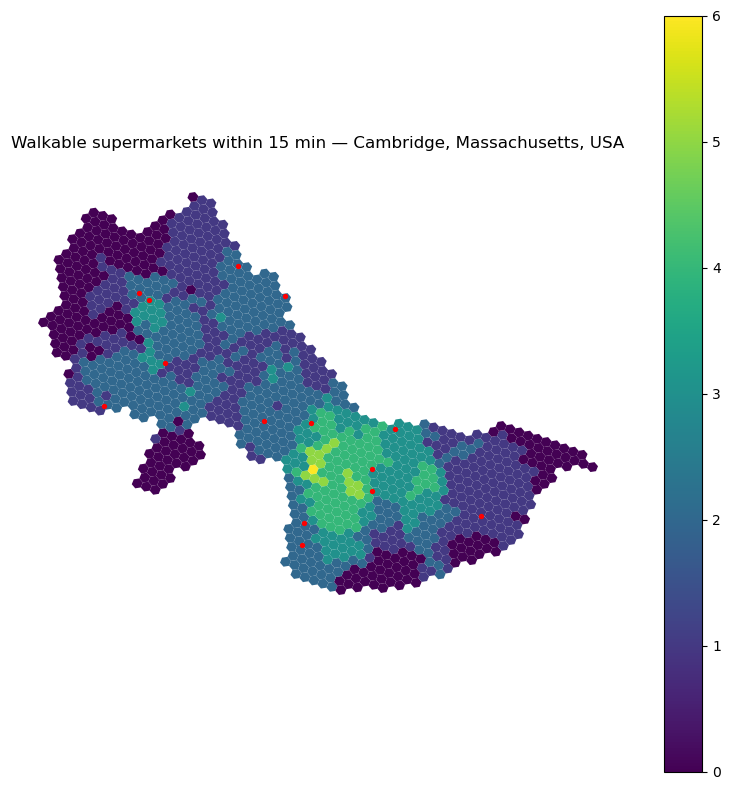

In [5]:
per_cell = cells['node_id'].map(acc[('15min', 'supermarkets')])
viz.plot_cell_values(
    cells, per_cell,
    title=f'Walkable supermarkets within 15 min — {PLACE}',
    overlays=[(supermarkets, {'color': 'red', 'markersize': 8})],
)
plt.tight_layout()
plt.show()